In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import fetch_asset_data, load_local_data
from stats_utils import adf_test, calculate_var, calculate_sharpe_ratio

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

TICKERS = ["TSLA", "BND", "SPY"]
START_DATE = "2015-01-01"
END_DATE = "2026-06-30"

In [2]:
# Run once to fetch and cache data locally
raw_data = fetch_asset_data(TICKERS, START_DATE, END_DATE)

tsla = raw_data["TSLA"]
bnd = raw_data["BND"]
spy = raw_data["SPY"]

tsla.tail()

Fetching TSLA...


[*********************100%***********************]  1 of 1 completed


Fetching BND...


[*********************100%***********************]  1 of 1 completed


Fetching SPY...


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2026-06-23,381.609985,381.609985,392.869995,379.059998,392.609985,50420200
2026-06-24,375.529999,375.529999,384.579987,373.049988,380.079987,37081400
2026-06-25,375.119995,375.119995,379.119995,371.220001,375.269989,30138800
2026-06-26,379.709991,379.709991,387.799988,368.600006,370.149994,53434100
2026-06-29,411.839996,411.839996,413.269989,379.299988,381.790009,57645800


In [7]:
def flatten_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

tsla = flatten_columns(tsla)
bnd = flatten_columns(bnd)
spy = flatten_columns(spy)

print(tsla.columns)  # should now just show: Open, High, Low, Close, Adj Close, Volume

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [8]:
for name, df in zip(TICKERS, [tsla, bnd, spy]):
    print(f"\n--- {name} ---")
    print(df.info())
    print(df.describe())


--- TSLA ---
<class 'pandas.DataFrame'>
DatetimeIndex: 2997 entries, 2015-01-02 to 2026-06-29
Freq: B
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2997 non-null   float64
 1   Close      2997 non-null   float64
 2   High       2997 non-null   float64
 3   Low        2997 non-null   float64
 4   Open       2997 non-null   float64
 5   Volume     2997 non-null   float64
dtypes: float64(6)
memory usage: 163.9 KB
None
Price    Adj Close        Close         High          Low         Open  \
count  2997.000000  2997.000000  2997.000000  2997.000000  2997.000000   
mean    149.169212   149.169212   152.376992   145.806181   149.175964   
std     139.205179   139.205179   142.152215   136.176395   139.273348   
min       9.578000     9.578000    10.331333     9.403333     9.488000   
25%      18.439333    18.439333    18.688667    18.169333    18.460667   
50%     133.455338   133.455338   136.243332   125.293

In [9]:
for name, df in zip(TICKERS, [tsla, bnd, spy]):
    missing = df.isna().sum()
    print(f"\n{name} missing values:\n{missing[missing > 0]}")


TSLA missing values:
Series([], dtype: int64)

BND missing values:
Series([], dtype: int64)

SPY missing values:
Series([], dtype: int64)


In [10]:
def clean_data(df):
    df = df.sort_index()
    df = df.asfreq("B")          # business-day frequency to expose gaps
    df = df.ffill()               # forward-fill non-trading gaps/holidays
    df = df.dropna()              # drop any remaining leading NaNs
    return df

tsla = clean_data(tsla)
bnd = clean_data(bnd)
spy = clean_data(spy)

print("Post-cleaning shapes:", tsla.shape, bnd.shape, spy.shape)

Post-cleaning shapes: (2997, 6) (2997, 6) (2997, 6)


In [11]:
combined = pd.DataFrame({
    "TSLA": tsla["Adj Close"],
    "BND": bnd["Adj Close"],
    "SPY": spy["Adj Close"]
}).dropna()

combined.to_csv("../data/processed/combined_prices.csv")
combined.tail()

,TSLA,BND,SPY
Date,,,
2026-06-23,381.609985,72.976631,733.580017
2026-06-24,375.529999,73.305534,733.239990
2026-06-25,375.119995,73.355370,734.299988
2026-06-26,379.709991,73.425133,728.989990
2026-06-29,411.839996,73.465004,741.000000


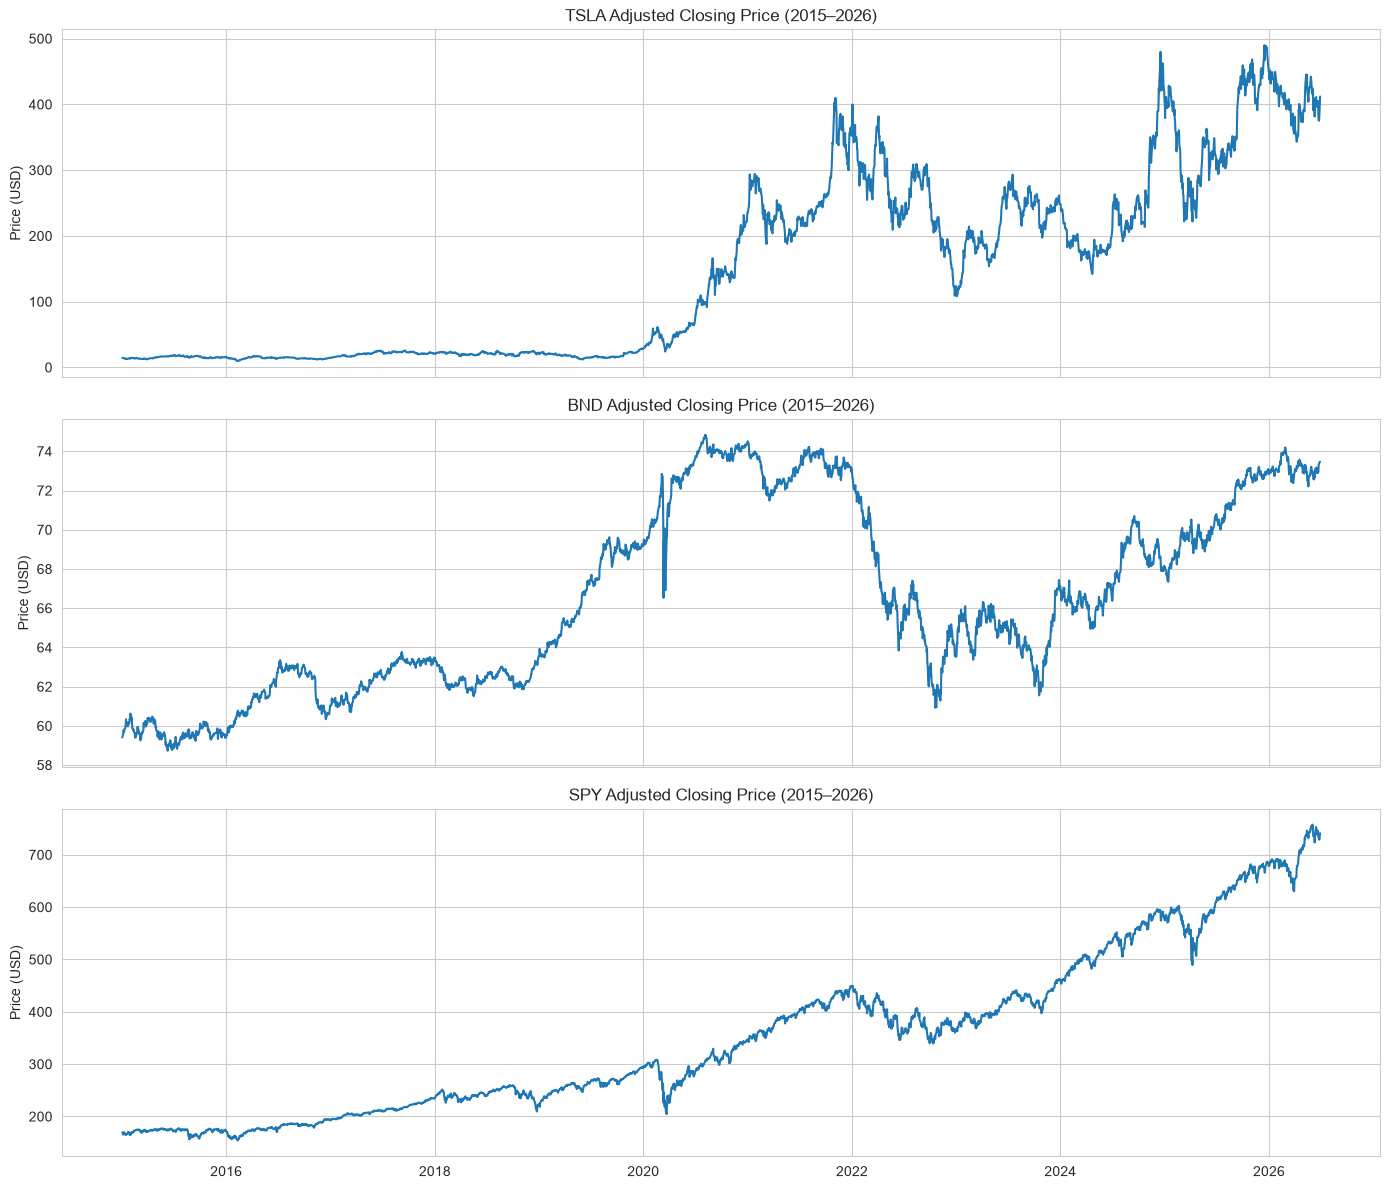

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, combined.columns):
    ax.plot(combined.index, combined[col])
    ax.set_title(f"{col} Adjusted Closing Price (2015–2026)")
    ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

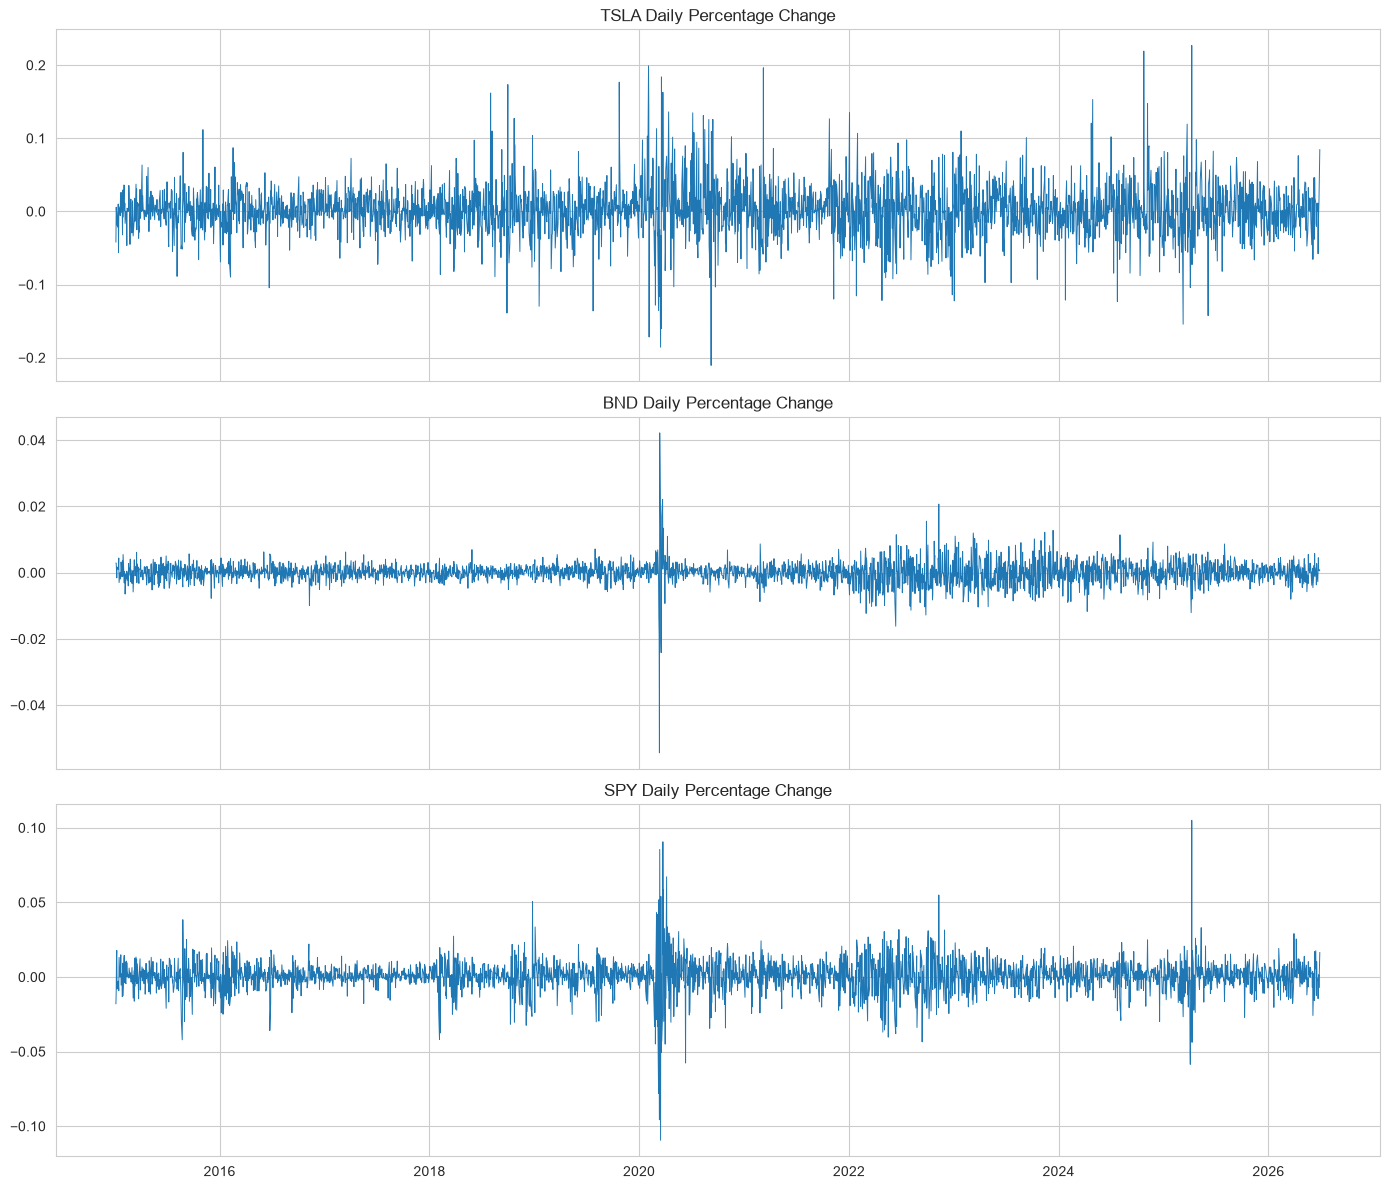

In [14]:
returns = combined.pct_change().dropna()
returns.to_csv("../data/processed/combined_returns.csv")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, returns.columns):
    ax.plot(returns.index, returns[col], linewidth=0.7)
    ax.set_title(f"{col} Daily Percentage Change")
plt.tight_layout()
plt.show()

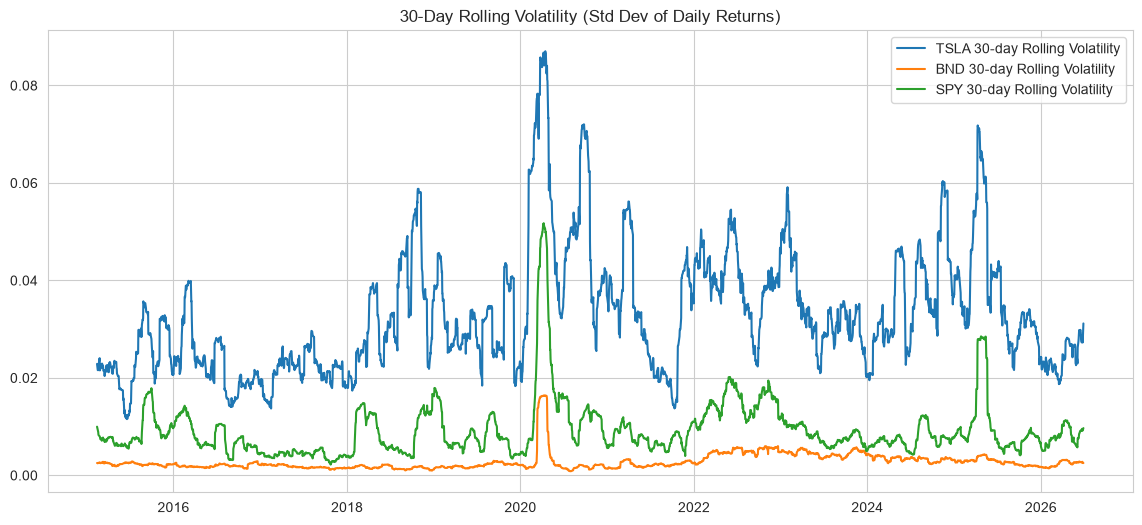

In [15]:
window = 30
rolling_mean = returns.rolling(window).mean()
rolling_std = returns.rolling(window).std()

fig, ax = plt.subplots(figsize=(14, 6))
for col in returns.columns:
    ax.plot(rolling_std.index, rolling_std[col], label=f"{col} 30-day Rolling Volatility")
ax.legend()
ax.set_title("30-Day Rolling Volatility (Std Dev of Daily Returns)")
plt.show()

In [16]:
def flag_outliers(returns_series, n_std=3):
    mean, std = returns_series.mean(), returns_series.std()
    threshold = n_std * std
    outliers = returns_series[(returns_series - mean).abs() > threshold]
    return outliers

for col in returns.columns:
    outliers = flag_outliers(returns[col])
    print(f"\n{col}: {len(outliers)} extreme return days (>3 std)")
    print(outliers.sort_values().tail(5))   # top 5 most extreme


TSLA: 50 extreme return days (>3 std)
Date
2020-03-19    0.183877
2021-03-09    0.196412
2020-02-03    0.198949
2024-10-24    0.219190
2025-04-09    0.226900
Name: TSLA, dtype: float64

BND: 35 extreme return days (>3 std)
Date
2022-09-28    0.015543
2020-03-20    0.016955
2022-11-10    0.020702
2020-03-23    0.022150
2020-03-13    0.042201
Name: BND, dtype: float64

SPY: 42 extreme return days (>3 std)
Date
2020-03-26    0.058390
2020-04-06    0.067166
2020-03-13    0.085486
2020-03-24    0.090603
2025-04-09    0.105019
Name: SPY, dtype: float64


In [17]:
adf_results = []

for col in combined.columns:
    adf_results.append(adf_test(combined[col], f"{col} - Price"))
    adf_results.append(adf_test(returns[col], f"{col} - Daily Return"))

adf_df = pd.DataFrame(adf_results)
adf_df

,series,ADF Statistic,p-value,Critical Values,Stationary
0,TSLA - Price,-1.038692,7.388921e-01,"{'1%': -3.432555920657187, '5%': -2.8625146314...",False
1,TSLA - Daily Return,-55.149764,0.000000e+00,"{'1%': -3.432535279976574, '5%': -2.8625055152...",True
2,BND - Price,-1.116590,7.084110e-01,"{'1%': -3.4325396703967974, '5%': -2.862507454...",False
3,BND - Daily Return,-21.277065,0.000000e+00,"{'1%': -3.4325396703967974, '5%': -2.862507454...",True
4,SPY - Price,1.433346,9.972605e-01,"{'1%': -3.4325551767781697, '5%': -2.862514302...",False
5,SPY - Daily Return,-15.700593,1.397684e-28,"{'1%': -3.4325440784940295, '5%': -2.862509401...",True


In [18]:
for _, row in adf_df.iterrows():
    verdict = "Stationary" if row["Stationary"] else "Non-Stationary"
    print(f"{row['series']}: p-value={row['p-value']:.4f} -> {verdict}")

TSLA - Price: p-value=0.7389 -> Non-Stationary
TSLA - Daily Return: p-value=0.0000 -> Stationary
BND - Price: p-value=0.7084 -> Non-Stationary
BND - Daily Return: p-value=0.0000 -> Stationary
SPY - Price: p-value=0.9973 -> Non-Stationary
SPY - Daily Return: p-value=0.0000 -> Stationary


In [19]:
risk_summary = []

for col in returns.columns:
    var_95 = calculate_var(returns[col], confidence=0.95)
    sharpe = calculate_sharpe_ratio(returns[col])
    risk_summary.append({"Asset": col, "VaR (95%)": var_95, "Sharpe Ratio (annualized)": sharpe})

risk_df = pd.DataFrame(risk_summary)
risk_df

,Asset,VaR (95%),Sharpe Ratio (annualized)
0,TSLA,-0.051096,0.744189
1,BND,-0.004724,-0.014744
2,SPY,-0.016354,0.687022
